# 02 — Preprocessing

Goals:
- Load raw LHCO2020 HDF5 safely (Blosc-compressed; requires `hdf5plugin`)
- Convert the `(N, 2100)` matrix into physics-aware features for ML
- Save compact features to `data/processed/` for training scripts and notebook 03

Output format:
- Saves `.npz` with arrays:
  - `X`: float32 feature matrix `(N, 128)`
  - `y`: int labels (0 for backgroundMC, -1 for unknown blackbox)
  - `meta`: small dict with preprocessing parameters + normalization stats

In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import h5py

try:
    import hdf5plugin  # noqa: F401
except Exception as exc:
    raise ImportError("Install hdf5plugin first: pip install hdf5plugin") from exc

RAW_DIR = Path('..') / 'data' / 'raw'
PROCESSED_DIR = Path('..') / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

FILES = sorted([*RAW_DIR.glob('*.h5'), *RAW_DIR.glob('*.hdf5')])
assert FILES, f"No HDF5 files found under {RAW_DIR.resolve()}"
for i, fp in enumerate(FILES):
    print(f"[{i}] {fp.name}")

DATASET_PATH = 'df/block0_values'

[0] events_LHCO2020_backgroundMC_Pythia.h5
[1] events_LHCO2020_BlackBox1.h5
[2] events_LHCO2020_BlackBox2.h5
[3] events_LHCO2020_BlackBox3.h5


Input: events_LHCO2020_backgroundMC_Pythia.h5
Output: features_K30_events_LHCO2020_backgroundMC_Pythia.npz
Label: 0
Saved: ..\data\processed\features_K30_events_LHCO2020_backgroundMC_Pythia.npz
X: (200000, 128) float32


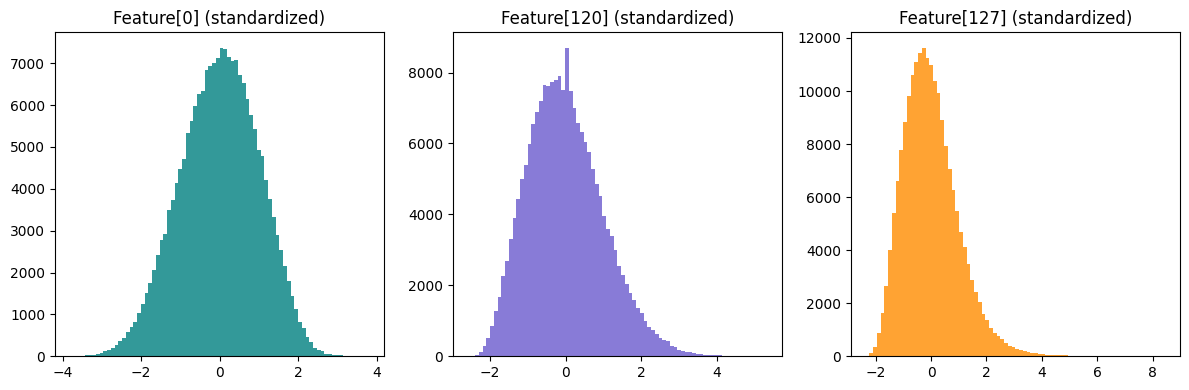

In [ ]:
# ---------------------------
# Preprocessing configuration
# ---------------------------
FILE_IDX = 0        # choose which raw file to preprocess
N_EVENTS = 50_000   # total events to process (raise if you have RAM)
START = 0           # start index in the raw dataset
CHUNK_EVENTS = 10_000  # processed per chunk to keep memory stable
K = 30              # number of leading particles to keep
DTYPE = np.float32

# Each particle: [log1p(pt), eta, sin(phi), cos(phi)] -> 4*K dims
# Event-level extras (8 dims) are appended to reach 128 dims total.
EVENT_EXTRA_DIMS = 8
FEATURE_DIM = 4 * K + EVENT_EXTRA_DIMS
assert FEATURE_DIM == 128, FEATURE_DIM

fp = FILES[FILE_IDX]
label = 0 if 'background' in fp.name.lower() else -1
out_path = PROCESSED_DIR / f"features_K{K}_{fp.stem}.npz"
print('Input:', fp.name)
print('Output:', out_path.name)
print('Label:', label)

# ---------------------------
# Robust raw loader
# ---------------------------
def load_raw_slice(fp: Path, *, start: int, stop: int) -> np.ndarray:
    with h5py.File(fp, 'r') as f:
        if DATASET_PATH not in f:
            raise KeyError(f"Expected '{DATASET_PATH}' in {fp.name}. Root keys={list(f.keys())}")
        dset = f[DATASET_PATH]
        n_total = int(dset.shape[0])
        if start < 0 or start >= n_total:
            raise ValueError(f"start must be in [0, {n_total}), got {start}")
        stop = min(int(stop), n_total)
        x = np.asarray(dset[start:stop], dtype=DTYPE)
        return x

# ---------------------------
# Feature engineering
# ---------------------------
def to_particles(x: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if x.shape[1] % 3 != 0:
        raise ValueError(f"Expected columns divisible by 3, got {x.shape[1]}")
    n_particles = x.shape[1] // 3
    p = x.reshape(x.shape[0], n_particles, 3)
    return p[..., 0], p[..., 1], p[..., 2]  # pt, eta, phi


def build_features(pt: np.ndarray, eta: np.ndarray, phi: np.ndarray, *, k: int) -> np.ndarray:
    """Return X with shape (N, 128) (unstandardized float32)."""
    present = pt > 0
    mult = present.sum(axis=1).astype(np.float32)

    # sort particles by pt descending (masked pads go to end)
    pt_for_sort = np.where(present, pt, -1.0)
    order = np.argsort(-pt_for_sort, axis=1)

    # take top-k
    idx = order[:, :k]
    row = np.arange(pt.shape[0])[:, None]
    pt_k = pt[row, idx]
    eta_k = eta[row, idx]
    phi_k = phi[row, idx]

    # particle features
    pt_k = np.log1p(np.maximum(pt_k, 0.0)).astype(np.float32)
    eta_k = np.clip(eta_k, -5.0, 5.0).astype(np.float32)
    sin_phi = np.sin(phi_k).astype(np.float32)
    cos_phi = np.cos(phi_k).astype(np.float32)

    part_feat = np.concatenate([pt_k, eta_k, sin_phi, cos_phi], axis=1)  # (N, 4k)

    # event-level extras (8)
    sum_pt = pt.sum(axis=1).astype(np.float32)
    leading_pt = pt.max(axis=1).astype(np.float32)
    mean_pt_nz = np.where(mult > 0, sum_pt / np.maximum(mult, 1), 0.0).astype(np.float32)
    std_pt_nz = np.sqrt(np.maximum(np.where(mult > 0, (pt**2).sum(axis=1) / np.maximum(mult, 1), 0.0) - mean_pt_nz**2, 0.0)).astype(np.float32)
    mean_abs_eta = np.where(mult > 0, (np.abs(eta) * present).sum(axis=1) / np.maximum(mult, 1), 0.0).astype(np.float32)

    # ht_top5: sum of top-5 pt
    pt_sorted = np.take_along_axis(pt_for_sort, order, axis=1)
    ht_top5 = np.maximum(pt_sorted[:, :5], 0.0).sum(axis=1).astype(np.float32)

    extras = np.stack([
        mult,
        np.log1p(sum_pt),
        sum_pt,
        leading_pt,
        mean_pt_nz,
        std_pt_nz,
        mean_abs_eta,
        ht_top5,
    ], axis=1).astype(np.float32)

    X = np.concatenate([part_feat, extras], axis=1).astype(np.float32)
    assert X.shape[1] == 128, X.shape
    return X


def standardize(X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    mean = X.mean(axis=0, dtype=np.float64).astype(np.float32)
    std = X.std(axis=0, dtype=np.float64).astype(np.float32)
    std = np.where(std > 1e-6, std, 1.0).astype(np.float32)
    Xn = ((X - mean) / std).astype(np.float32)
    return Xn, mean, std

# ---------------------------
# Run preprocessing (chunked)
# ---------------------------
X_chunks = []
end = START + int(N_EVENTS)
cur = START
while cur < end:
    nxt = min(end, cur + int(CHUNK_EVENTS))
    print(f"Loading events [{cur}:{nxt}) ...")
    raw = load_raw_slice(fp, start=cur, stop=nxt)
    pt, eta, phi = to_particles(raw)
    Xc = build_features(pt, eta, phi, k=K)
    X_chunks.append(Xc)
    cur = nxt

X = np.concatenate(X_chunks, axis=0).astype(np.float32)
Xn, mean, std = standardize(X)
y = np.full((Xn.shape[0],), int(label), dtype=np.int64)

meta = {
    'k': int(K),
    'feature_dim': int(Xn.shape[1]),
    'particle_features': ['log1p_pt', 'eta', 'sin_phi', 'cos_phi'],
    'extras': ['mult', 'log1p_sum_pt', 'sum_pt', 'leading_pt', 'mean_pt', 'std_pt', 'mean_abs_eta', 'ht_top5'],
    'start': int(START),
    'n_events': int(Xn.shape[0]),
    'chunk_events': int(CHUNK_EVENTS),
}

np.savez_compressed(
    out_path,
    X=Xn,
    y=y,
    mean=mean,
    std=std,
    meta=meta,
    source_file=str(fp.name),
    dtype=str(DTYPE),
 )

print('Saved:', out_path)
print('X:', Xn.shape, Xn.dtype)

# Quick sanity plots (a few feature columns)
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.hist(Xn[:, 0], bins=80, color='teal', alpha=0.8)
plt.title('Feature[0] (standardized)')
plt.subplot(1, 3, 2)
plt.hist(Xn[:, 120], bins=80, color='slateblue', alpha=0.8)
plt.title('Feature[120] (standardized)')
plt.subplot(1, 3, 3)
plt.hist(Xn[:, 127], bins=80, color='darkorange', alpha=0.8)
plt.title('Feature[127] (standardized)')
plt.tight_layout()